最终版
最终注意力机制版
最终版
最终注意力机制版
25.11.25
修改注意力机制窗口大小为10
logo图画布宽度修改为一致大小
热图背景为白色
颜色统一风格
2025.12.30新增回归图


In [1]:
#import package
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from transformers import AutoModel, AutoTokenizer
from sklearn.metrics import matthews_corrcoef, roc_auc_score, roc_curve
from sklearn.model_selection import KFold, train_test_split
from sklearn.linear_model import LogisticRegression
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import csv
import os

import logomaker
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats
import os


c:\anaconda\envs\pytorch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#Calculation of indicators and dataset definitions计算性能指标 和 自定义数据集类

def calculate_metrics2(labels, scores, threshold):

    sorted_indices = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)
    binary_predictions = [1 if scores[i] >= threshold else 0 for i in sorted_indices]
    TP = sum([1 for i in range(len(labels)) if labels[i] == 1 and binary_predictions[i] == 1])
    FP = sum([1 for i in range(len(labels)) if labels[i] == 0 and binary_predictions[i] == 1])
    TN = sum([1 for i in range(len(labels)) if labels[i] == 0 and binary_predictions[i] == 0])
    FN = sum([1 for i in range(len(labels)) if labels[i] == 1 and binary_predictions[i] == 0])
    recall = TP / (TP + FN) if TP + FN > 0 else 0.0
    specificity = TN / (TN + FP) if TN + FP > 0 else 0.0
    sensitivity = recall
    precision = TP / (TP + FP) if TP + FP > 0 else 0.0
    return recall, specificity, sensitivity, precision


def update_best_metrics(acc, auc, mcc, recall, specificity, sensitivity, precision, metrics):
    best_acc, best_auc, best_mcc, best_recall, best_spec, best_sens, best_prec = metrics
    updated = False
    # 主要以AUC作为更新最佳模型的标准
    if auc >= best_auc:
        best_acc = acc
        best_auc = auc
        best_mcc = mcc
        best_recall = recall
        best_spec = specificity
        best_sens = sensitivity
        best_prec = precision
        updated = True
    return (best_acc, best_auc, best_mcc, best_recall, best_spec, best_sens, best_prec), updated

class UmamiDataset(Dataset):
    """
    修改后的数据集类，用于读取 Positive 和 Negative 两个 .txt 文件
    """
    def __init__(self, positive_file, negative_file):
        # 合并读取正面和负面序列
        self.sequences, self.labels = self._read_files(positive_file, negative_file)

    def _read_fasta_sequences(self, file_path):
        """辅助函数，用于从 FASTA 格式的 .txt 文件中提取序列"""
        sequences = []
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                # 忽略以'>'开头的标题行和空行
                if not line.startswith('>') and line.strip():
                    sequences.append(line.strip())
        return sequences

    def _read_files(self, positive_file, negative_file):
        """读取正面和负面文件，并分配标签"""
        pos_sequences = self._read_fasta_sequences(positive_file)
        neg_sequences = self._read_fasta_sequences(negative_file)

        # 合并序列
        all_sequences = pos_sequences + neg_sequences
        # 创建对应的标签 (1 for positive, 0 for negative)
        all_labels = [1] * len(pos_sequences) + [0] * len(neg_sequences)

        return all_sequences, all_labels

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        # 返回序列和标签
        sample = self.sequences[index]
        label = self.labels[index]
        return sample, label

In [3]:
# 鲜味肽的预测模型定义_新增注意力机制可视化

class UmamiESM6Model(nn.Module):
    def __init__(self):
        super(UmamiESM6Model, self).__init__()
        # facebook/esm2_t6_8M_UR50D 模型有6个注意力层和320的隐藏维度
        self.model = AutoModel.from_pretrained("facebook/esm2_t6_8M_UR50D")
        self.tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t6_8M_UR50D")
        self.classifier = nn.Linear(320, 2)

    def forward(self, inputs):
        # 对输入序列进行编码
        encoded_inputs = self.tokenizer(inputs, padding=True, truncation=True, return_tensors="pt")
        input_ids = encoded_inputs["input_ids"].to(device)
        attention_mask = encoded_inputs["attention_mask"].to(device)
        
        # 将输入传递给 ESM 模型，并请求输出注意力分数
        # outputs 对象现在将包含一个名为 'attentions' 的属性
        outputs = self.model(
            input_ids=input_ids, 
            attention_mask=attention_mask,
            output_attentions=True  # <-- 关键改动在这里
        )
        
        # 'attentions' 是一个元组，包含了模型每一层的注意力张量
        # 每个张量的形状为: (batch_size, num_heads, sequence_length, sequence_length)
        attentions = outputs.attentions
        
        # 使用池化后的输出进行分类
        pooler_output = outputs.pooler_output   
        logits = self.classifier(pooler_output)
        
        # 返回用于预测的 logits 和用于可视化的 attentions
        return logits, attentions, input_ids

In [4]:
# --- 训练集 (UMP-TR) ---
train_pos_file = r'E:/LLM+XWT/XWT数据/iUmami-SCM-UMP442/training (named UMP-TR)/train-positive.txt'
train_neg_file = r'E:/LLM+XWT/XWT数据/iUmami-SCM-UMP442/training (named UMP-TR)/train-negative.txt'
train_dataset = UmamiDataset(train_pos_file, train_neg_file)

# --- 独立测试集 (UMP-IND) ---
test_pos_file = r'E:/LLM+XWT/XWT数据/iUmami-SCM-UMP442/independent sets (named UMP-IND)/test-positive.txt'
test_neg_file = r'E:/LLM+XWT/XWT数据/iUmami-SCM-UMP442/independent sets (named UMP-IND)/test-negative.txt'
test_dataset = UmamiDataset(test_pos_file, test_neg_file)

# 打印数据集大小信息
print(f"训练集 UMP-TR 加载完成: {len(train_dataset)} 个样本")
print(f"独立测试集 UMP-IND 加载完成: {len(test_dataset)} 个样本")

训练集 UMP-TR 加载完成: 353 个样本
独立测试集 UMP-IND 加载完成: 89 个样本


In [5]:
#Model loading and setting

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random_seed = 2025
loss_all=99999
metrics = (0, 0, 0,0,0,0,0)  
best_epoch = 0
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)
torch.cuda.manual_seed(random_seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
criterion = nn.CrossEntropyLoss()
model = UmamiESM6Model()
model.to(device)#Model loading
learning_rates=0.000065 #Setting learning rates
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rates)

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [6]:
print("--- 开始在 UMP-TR 数据集上进行10折交叉验证 ---")

# KFold 设置
kf = KFold(n_splits=10, shuffle=True, random_state=random_seed)
cv_results = {'acc': [], 'auc': [], 'mcc': [], 'spec': [], 'sens': []}

# 将数据集转换为Numpy数组以便切分
sequences_np = np.array(train_dataset.sequences)
labels_np = np.array(train_dataset.labels)

for fold, (train_idx, val_idx) in enumerate(kf.split(sequences_np)):
    print(f"\n===== 折叠 {fold + 1}/10 =====")

    # --- 为当前折叠创建数据集和加载器 ---
    train_subset = Subset(train_dataset, train_idx)
    val_subset = Subset(train_dataset, val_idx)
    
    train_dataloader = DataLoader(train_subset, batch_size=32, shuffle=True)
    val_dataloader = DataLoader(val_subset, batch_size=32)

    # --- 为每个折叠重新初始化模型 ---
    model = UmamiESM6Model()
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=6.5e-5)
    # 计算类别权重 (1/类别数量)，给样本少的类别更高的权重
    # 训练集中负样本(0)有241个，正样本(1)有112个
    weights = torch.tensor([1/241, 1/112], dtype=torch.float).to(device)
    
    # 定义带权重的损失函数
    criterion = nn.CrossEntropyLoss(weight=weights)
    
    # --- 在当前折叠上训练和验证 (50个Epochs) ---
    for epoch in range(50):
        model.train()
        for batch_data, batch_labels in train_dataloader:
            batch_labels = batch_labels.to(device)
            logits, _, _ = model(list(batch_data))
            loss = criterion(logits, batch_labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # --- 在验证集上评估当前折叠的最佳性能 ---
    model.eval()
    all_val_labels = []
    all_val_scores = []
    with torch.no_grad():
        for batch_data, batch_labels in val_dataloader:
            logits, _, _ = model(list(batch_data))
            probabilities = nn.functional.softmax(logits, dim=1)
            scores = probabilities[:, 1]
            all_val_labels.extend(batch_labels.cpu().tolist())
            all_val_scores.extend(scores.cpu().tolist())

    # 计算指标
    val_auc = roc_auc_score(all_val_labels, all_val_scores)
    predicted_labels = (np.array(all_val_scores) >= 0.5).astype(int)
    val_acc = np.mean(predicted_labels == np.array(all_val_labels))
    val_mcc = matthews_corrcoef(all_val_labels, predicted_labels)
    _, val_spec, val_sens, _ = calculate_metrics2(all_val_labels, all_val_scores, 0.5)
    
    # [新代码] 打印当前折叠的所有性能指标
    print(f"--- 折叠 {fold + 1} 性能 ---")
    print(f"  ACC: {val_acc:.4f}")
    print(f"  AUC: {val_auc:.4f}")
    print(f"  MCC: {val_mcc:.4f}")
    print(f"  SPEC: {val_spec:.4f}")
    print(f"  SENS: {val_sens:.4f}")
    cv_results['auc'].append(val_auc)
    cv_results['acc'].append(val_acc)
    cv_results['mcc'].append(val_mcc)
    cv_results['spec'].append(val_spec)
    cv_results['sens'].append(val_sens)

# --- 3. 报告交叉验证的平均结果 ---
print("\n===== 10折交叉验证平均结果 (在UMP-TR上) =====")
for metric, values in cv_results.items():
    print(f"  平均 {metric.upper()}: {np.mean(values):.4f} ± {np.std(values):.4f}")

# --- 4. 在完整的UMP-TR上训练最终模型，并在UMP-IND上评估 ---
print("\n===== 在完整UMP-TR上训练最终模型 =====")
full_train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32)

final_model = UmamiESM6Model()
final_model.to(device)
optimizer = torch.optim.Adam(final_model.parameters(), lr=6.5e-5)
weights = torch.tensor([1/241, 1/112], dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

for epoch in range(50):
    final_model.train()
    for batch_data, batch_labels in full_train_dataloader:
        batch_labels = batch_labels.to(device)
        logits, _, _ = final_model(list(batch_data)) # 将 outputs 解包
        loss = criterion(logits, batch_labels) # 使用 logits 计算损失
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f"最终模型训练中... Epoch {epoch+1}/50")


--- 开始在 UMP-TR 数据集上进行10折交叉验证 ---

===== 折叠 1/10 =====


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


--- 折叠 1 性能 ---
  ACC: 0.8611
  AUC: 0.9567
  MCC: 0.7233
  SPEC: 1.0000
  SENS: 0.9474

===== 折叠 2/10 =====


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


--- 折叠 2 性能 ---
  ACC: 0.9167
  AUC: 0.9464
  MCC: 0.7715
  SPEC: 0.9643
  SENS: 1.0000

===== 折叠 3/10 =====


...

--- 折叠 9 性能 ---
  ACC: 0.7429
  AUC: 0.8816
  MCC: 0.4907
  SPEC: 1.0000
  SENS: 0.6875

===== 折叠 10/10 =====


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


--- 折叠 10 性能 ---
  ACC: 0.9429
  AUC: 0.9811
  MCC: 0.8674
  SPEC: 1.0000
  SENS: 1.0000

===== 10折交叉验证平均结果 (在UMP-TR上) =====
  平均 ACC: 0.8411 ± 0.0682
  平均 AUC: 0.9169 ± 0.0527
  平均 MCC: 0.6268 ± 0.1649
  平均 SPEC: 0.9699 ± 0.0563
  平均 SENS: 0.9285 ± 0.1104

===== 在完整UMP-TR上训练最终模型 =====


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


最终模型训练中... Epoch 10/50
最终模型训练中... Epoch 20/50
最终模型训练中... Epoch 30/50
最终模型训练中... Epoch 40/50
最终模型训练中... Epoch 50/50


In [7]:

print("\n===== 在独立测试集(UMP-IND)上评估最终模型并提取注意力 =====")
final_model.eval()

all_test_labels = []
all_test_scores = []

# 这个列表将储存可视化所需的所有数据
attention_visualization_data = [] 

with torch.no_grad():
    # 我们使用原始的 test_dataset 来获取序列字符串
    test_dataloader = DataLoader(test_dataset, batch_size=32)

    for i, (batch_data, batch_labels) in enumerate(test_dataloader):
        # 修改后的模型现在返回三个值
        logits, attentions, input_ids = final_model(list(batch_data))
        
        probabilities = nn.functional.softmax(logits, dim=1)
        scores = probabilities[:, 1]
        
        all_test_labels.extend(batch_labels.cpu().tolist())
        all_test_scores.extend(scores.cpu().tolist())

        # --- 储存用于可视化的数据 ---
        # 将张量从计算图中分离并移至 CPU
        attentions_cpu = [att.cpu().numpy() for att in attentions]
        input_ids_cpu = input_ids.cpu().numpy()
        labels_cpu = batch_labels.cpu().numpy()

        # 遍历批次中的每个样本
        for j in range(len(batch_data)):
            sequence = batch_data[j]
            label = labels_cpu[j]
            # 获取当前序列的 token 列表
            tokens = final_model.tokenizer.convert_ids_to_tokens(input_ids_cpu[j])
            # 过滤掉 padding token
            seq_len = len(sequence) + 2 # 加上 [CLS] 和 [SEP]

            # 从批次中提取当前单个序列的注意力分数
            # 为简化起见，我们在这里对所有注意力头（heads）取平均
            # Averaged attentions shape: (num_layers, seq_len, seq_len)
            sequence_attentions = [np.mean(att[j, :, :seq_len, :seq_len], axis=0) for att in attentions_cpu]

            attention_visualization_data.append({
                'sequence': sequence,
                'label': label,
                'tokens': tokens[:seq_len],
                'attentions': np.array(sequence_attentions) # 形状: (layers, seq_len, seq_len)
            })

print("注意力数据提取完成。")
# 计算最终性能指标
final_predicted_labels = (np.array(all_test_scores) >= 0.5).astype(int)
final_acc = np.mean(final_predicted_labels == np.array(all_test_labels))
final_auc = roc_auc_score(all_test_labels, all_test_scores)
final_mcc = matthews_corrcoef(all_test_labels, final_predicted_labels)
_, final_spec, final_sens, _ = calculate_metrics2(all_test_labels, all_test_scores, 0.5)

print("\n--- 独立测试集性能 (UMP-IND) ---")
print(f"  AUC: {final_auc:.4f}")
print(f"  ACC: {final_acc:.4f}")
print(f"  MCC: {final_mcc:.4f}")
print(f"  Specificity: {final_spec:.4f}")
print(f"  Sensitivity (Recall): {final_sens:.4f}")
print("="*50)

# #为独立测试集绘制ROC曲线 ---
# from sklearn.metrics import roc_curve
# fpr, tpr, _ = roc_curve(all_test_labels, all_test_scores)

# plt.figure(figsize=(8, 7))
# plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {final_auc:.4f})')
# plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
# plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
# plt.title('ROC Curve on Independent Test Set (UMP-IND)', fontsize=14)
# plt.legend(loc="lower right")
# plt.grid(True)

# # 注意：请确保保存路径存在，否则会报错
# save_path = r'E:/LLM+XWT/实验结果/UmamiESM6Model/UmamiESM6Model_UMP442_IND_ROC_Curve_7学习率.png'
# plt.savefig(save_path, dpi=400)
# print(f"\nROC曲线已保存至: {save_path}")

# plt.show()



===== 在独立测试集(UMP-IND)上评估最终模型并提取注意力 =====
注意力数据提取完成。

--- 独立测试集性能 (UMP-IND) ---
  AUC: 0.9596
  ACC: 0.8989
  MCC: 0.7744
  Specificity: 0.9508
  Sensitivity (Recall): 1.0000


In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logomaker

# ===============================
#   0) 全局绘图风格设置 (参考 Five_fold_esm_XWT_2_6.ipynb)
# ===============================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['font.size'] = 22

# ===============================
#   氨基酸化学性质配色方案
# ===============================
aa_color_map = {
    'A': 'lightgray', 'V': 'lightgray', 'L': 'lightgray', 'I': 'lightgray',
    'M': 'lightgray', 'F': 'lightgray', 'W': 'lightgray', 'P': 'lightgray', 'G': 'lightgray',  # 非极性
    'S': 'orange', 'T': 'orange', 'Y': 'orange', 'C': 'orange', 'N': 'orange', 'Q': 'orange',  # 极性
    'D': 'red', 'E': 'red',   # 酸性
    'K': 'blue', 'R': 'blue', 'H': 'blue'  # 碱性
}

# ===============================
#   1) 氨基酸重要性分析
# ===============================
def analyze_amino_acid_importance_upgraded(visualization_data, amino_acids, output_dir):
    """
    计算氨基酸的重要性：平均注意力 + 频率 + 综合重要性。
    """
    print("--- 开始运行 [升级版] 氨基酸重要性分析 ---")
    

    BORDER_WIDTH = 4     # 画框线条粗细 (默认约为1，这里设为4)
    TICK_WIDTH = 4       # 刻度线粗细
    TICK_LENGTH = 10     # 刻度线长度
    LABEL_SIZE = 32      # XY轴标签字体大小
    TICK_FONT_SIZE = 28  # 刻度文字大小
    umami_data = [d for d in visualization_data if d['label'] == 1]    

    # 1. 平均注意力
    attention_scores = {aa: [] for aa in amino_acids}
    for data in umami_data:
        avg_layer_attentions = np.mean(data['attentions'], axis=0)
        cls_to_tokens_attention = avg_layer_attentions[0, :]
        for i, token in enumerate(data['tokens'][1:-1]):
            if token in attention_scores:
                attention_scores[token].append(cls_to_tokens_attention[i+1])
    
    avg_attention = {aa: np.mean(scores) if scores else 0 for aa, scores in attention_scores.items()}
    df_attention = pd.DataFrame(list(avg_attention.items()), columns=['Amino Acid', 'Average Attention']).sort_values(by='Average Attention', ascending=False)
    
    # 2. 出现频率
    frequency_counts = {aa: 0 for aa in amino_acids}
    total_aas = 0
    for data in umami_data:
        for token in data['sequence']:
            if token in frequency_counts:
                frequency_counts[token] += 1
                total_aas += 1
    
    frequency = {aa: count / total_aas if total_aas > 0 else 0 for aa, count in frequency_counts.items()}
    df_frequency = pd.DataFrame(list(frequency.items()), columns=['Amino Acid', 'Frequency']).sort_values(by='Frequency', ascending=False)
    
    # 3. 综合重要性
    combined_importance = {aa: avg_attention.get(aa, 0) * frequency.get(aa, 0) for aa in amino_acids}
    df_combined = pd.DataFrame(list(combined_importance.items()), columns=['Amino Acid', 'Combined Importance']).sort_values(by='Combined Importance', ascending=False)
    
    # ===============================
    # 4. 可视化 (去除了标题)
    # ===============================
    def apply_plot_style(ax):
        # 加粗边框 (Spines)
        for spine in ax.spines.values():
            spine.set_linewidth(BORDER_WIDTH)
        # 加粗刻度线并调整字体
        ax.tick_params(width=TICK_WIDTH, length=TICK_LENGTH, labelsize=TICK_FONT_SIZE)
        # 确保X轴和Y轴的刻度文字也是粗体
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_weight('bold')    

    # --- 平均注意力条形图 ---
    plt.figure(figsize=(18, 10))
    # 获取 axes 对象
    ax = sns.barplot(
        x='Amino Acid',
        y='Average Attention',
        data=df_attention,
        palette=[aa_color_map[aa] for aa in df_attention['Amino Acid']]
    )
    
    # 应用样式
    apply_plot_style(ax)
    
    plt.xlabel('Amino Acid', fontsize=LABEL_SIZE, fontweight='bold')
    plt.ylabel('Average Attention', fontsize=LABEL_SIZE, fontweight='bold')
    
    save_path_att = os.path.join(output_dir, 'importance_average_attention.png')
    #plt.savefig(save_path_att, dpi=600, bbox_inches='tight')
    plt.show()

    # --- 出现频率条形图 ---
    plt.figure(figsize=(18, 10))
    ax = sns.barplot(
        x='Amino Acid',
        y='Frequency',
        data=df_frequency,
        palette=[aa_color_map[aa] for aa in df_frequency['Amino Acid']]
    )
    
    # 应用样式
    apply_plot_style(ax)
    
    plt.xlabel('Amino Acid', fontsize=LABEL_SIZE, fontweight='bold')
    plt.ylabel('Frequency', fontsize=LABEL_SIZE, fontweight='bold')
    
    save_path_freq = os.path.join(output_dir, 'importance_frequency.png')
    #plt.savefig(save_path_freq, dpi=600, bbox_inches='tight')
    plt.show()

    # --- 综合重要性条形图 ---
    plt.figure(figsize=(18, 10))
    ax = sns.barplot(
        x='Amino Acid',
        y='Combined Importance',
        data=df_combined,
        palette=[aa_color_map[aa] for aa in df_combined['Amino Acid']]
    )
    
    # 应用样式
    apply_plot_style(ax)

    plt.xlabel('Amino Acid', fontsize=LABEL_SIZE, fontweight='bold')
    plt.ylabel('Combined Importance Score', fontsize=LABEL_SIZE, fontweight='bold')
    
    save_path_comb = os.path.join(output_dir, 'importance_combined.png')
    #plt.savefig(save_path_comb, dpi=600, bbox_inches='tight')
    plt.show()
    
    return df_combined

In [9]:
# ===============================
#   2) 基序热力图 & 序列 Logo (无Colorbar版)
# ===============================
def analyze_motif_heatmap_upgraded(visualization_data, central_aa, amino_acids, window_size, output_dir, 
                                   vmin=0.06, vmax=0.17):
    
    print(f"\n--- 开始为核心氨基酸 '{central_aa}' 生成热力图与序列Logo (无Colorbar) ---")
    
    aa_map = {aa: i for i, aa in enumerate(amino_acids)}
    num_aas = len(amino_acids)
    matrix_shape = (num_aas, 2 * window_size + 1)
    
    attention_matrix = np.zeros(matrix_shape)
    count_matrix = np.zeros(matrix_shape)
    
    umami_data = [d for d in visualization_data if d['label'] == 1]

    # === 计算注意力矩阵 ===
    for data in umami_data:
        avg_layer_attentions = np.mean(data['attentions'], axis=0)
        tokens = data['tokens']
        for i, token in enumerate(tokens):
            if token == central_aa:
                for j, neighbor_token in enumerate(tokens):
                    if neighbor_token not in aa_map:
                        continue
                    relative_pos = j - i
                    if -window_size <= relative_pos <= window_size and relative_pos != 0:
                        row_idx = aa_map[neighbor_token]
                        col_idx = relative_pos + window_size
                        bidirectional_attention = (avg_layer_attentions[i, j] + avg_layer_attentions[j, i]) / 2
                        attention_matrix[row_idx, col_idx] += bidirectional_attention
                        count_matrix[row_idx, col_idx] += 1

    count_matrix[count_matrix == 0] = 1
    avg_attention_matrix = attention_matrix / count_matrix
    
    # === 准备X轴标签 ===
    xtick_labels = [str(i) for i in range(-window_size, window_size + 1)]
    xtick_labels[window_size] = f'({central_aa})'

    # ===========================
    #      绘制热力图 (无Cbar)
    # ===========================
    fig_width = 20 
    fig_height = 10
    
    plt.figure(figsize=(fig_width, fig_height))
    mask = (avg_attention_matrix == 0)

    ax = sns.heatmap(
        avg_attention_matrix,
        mask=mask,
        cmap='Reds',
        vmin=vmin,
        vmax=vmax,
        annot=True, fmt=".2f",
        xticklabels=xtick_labels,
        yticklabels=amino_acids,
        cbar=False,  # 强制关闭 Colorbar
        annot_kws={"size": 16, "weight": "bold"},
        square=False
    )

    # 中间列处理
    center_col = window_size
    for row in range(num_aas):
        for text in list(ax.texts):
            col, r = int(text.get_position()[0] - 0.5), int(text.get_position()[1] - 0.5)
            if col == center_col and r == row:
                text.remove()
        ax.text(center_col + 0.5, row + 0.5, central_aa,
                ha='center', va='center', color='black',
                fontsize=20, fontweight='bold')

    # 隐藏极小值
    for text in ax.texts:
        try:
            if abs(float(text.get_text())) < 1e-6:
                text.set_visible(False)
        except:
            pass

    ax.tick_params(axis='y', labelsize=32, labelrotation=0)#字号修改-------
    ax.tick_params(axis='x', labelsize=32)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')

    save_path_heatmap = os.path.join(output_dir, f'motif_heatmap_{central_aa}.png')
    #plt.savefig(save_path_heatmap, dpi=600, bbox_inches='tight')
    plt.show()

    # ===========================
    #      绘制序列 Logo 图
    # ===========================
    # 使用 add_axes 方式确保边距控制更精确
    fig = plt.figure(figsize=(fig_width, 6))
    # 调整绘图区域 [left, bottom, width, height] 以填满画布
    # 这里给一点边距防止标签被切
    ax = fig.add_axes([0.05, 0.15, 0.90, 0.75]) 
    
    logo_df = pd.DataFrame(
        avg_attention_matrix.T,
        columns=amino_acids,
        index=range(-window_size, window_size + 1)
    ).clip(lower=0)
    
    pos_sum = logo_df.sum(axis=1)
    max_pos_sum = float(pos_sum.max()) if float(pos_sum.max()) > 0 else 1.0
    logo_df = logo_df / max_pos_sum
    logo_df.loc[0, :] = 0.0
    logo_df.loc[0, central_aa] = 1.0

    logo = logomaker.Logo(logo_df, ax=ax, color_scheme=aa_color_map)
    logo.style_spines(visible=False)
    logo.style_spines(spines=['left', 'bottom'], visible=True)
    logo.ax.set_ylim(0, 1.02)
    
    # 强制X轴范围与刻度
    logo.ax.set_xlim([-window_size - 0.5, window_size + 0.5])
    logo.ax.set_xticks(range(-window_size, window_size + 1))
    logo.ax.set_xticklabels(xtick_labels)

    logo.ax.tick_params(axis='x', labelsize=42)#字号修改-------
    logo.ax.tick_params(axis='y', labelsize=42)
    for label in logo.ax.get_xticklabels() + logo.ax.get_yticklabels():
        label.set_fontweight('bold')

    plt.title("")
    plt.xlabel("")
    plt.ylabel("")

    save_path_logo = os.path.join(output_dir, f'motif_logo_{central_aa}.png')
    #plt.savefig(save_path_logo, dpi=600, bbox_inches='tight')
    plt.show()

import matplotlib as mpl

# ===============================
#   3) 生成独立 Colorbar
# ===============================
def generate_standalone_colorbar(output_dir, vmin=0.06, vmax=0.17, cmap='Reds', height=10):
    print("\n--- 生成独立 Colorbar ---")
    
    # 创建一个窄长的画布
    # 宽度设为 2 (足够显示条带和数字)，高度设为 10 (与热力图一致)
    fig, ax = plt.figure(figsize=(0.5, height)), plt.gca()#热图宽度修改-----------
    
    # 定义 Normalize 和 Colormap
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap_obj = plt.get_cmap(cmap)
    
    # 创建 Colorbar
    cb = mpl.colorbar.ColorbarBase(
        ax, 
        cmap=cmap_obj,
        norm=norm,
        orientation='vertical'
    )
    
    # 调整刻度字体
    cb.ax.tick_params(labelsize=30, width=2)#colorbar字号修改-------
    for label in cb.ax.get_yticklabels():
        label.set_fontweight('bold')
        
    # 保存
    save_path = os.path.join(output_dir, 'standalone_colorbar.png')
    #plt.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.show()
    print(f"独立 Colorbar 已保存至: {save_path}")


--- 开始运行 [升级版] 氨基酸重要性分析 ---


C:\Users\pc\AppData\Local\Temp\ipykernel_10696\3858025875.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


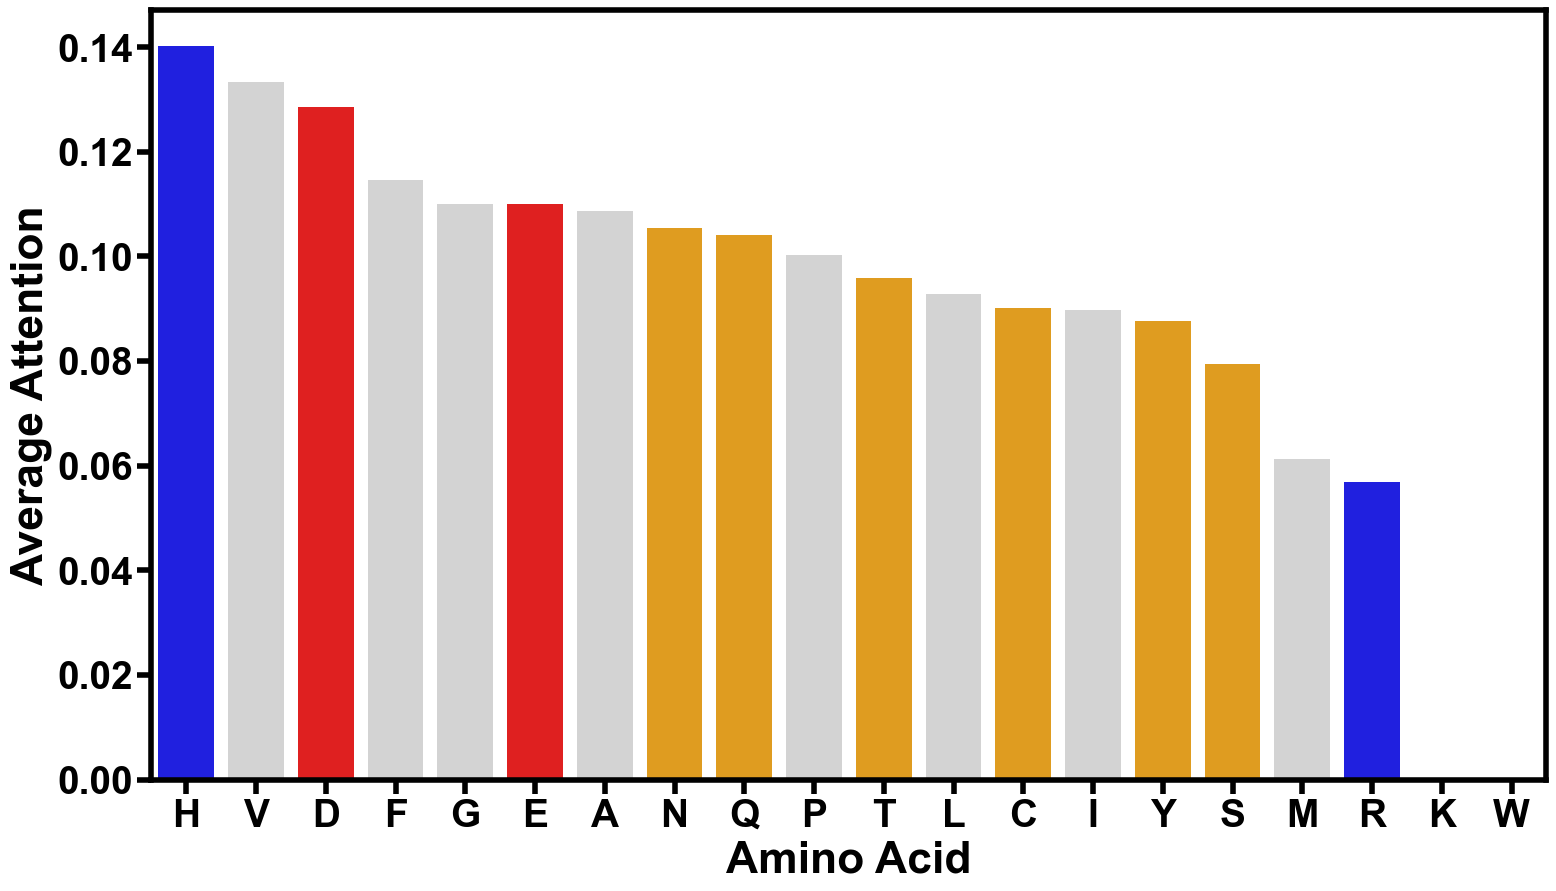

C:\Users\pc\AppData\Local\Temp\ipykernel_10696\3858025875.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


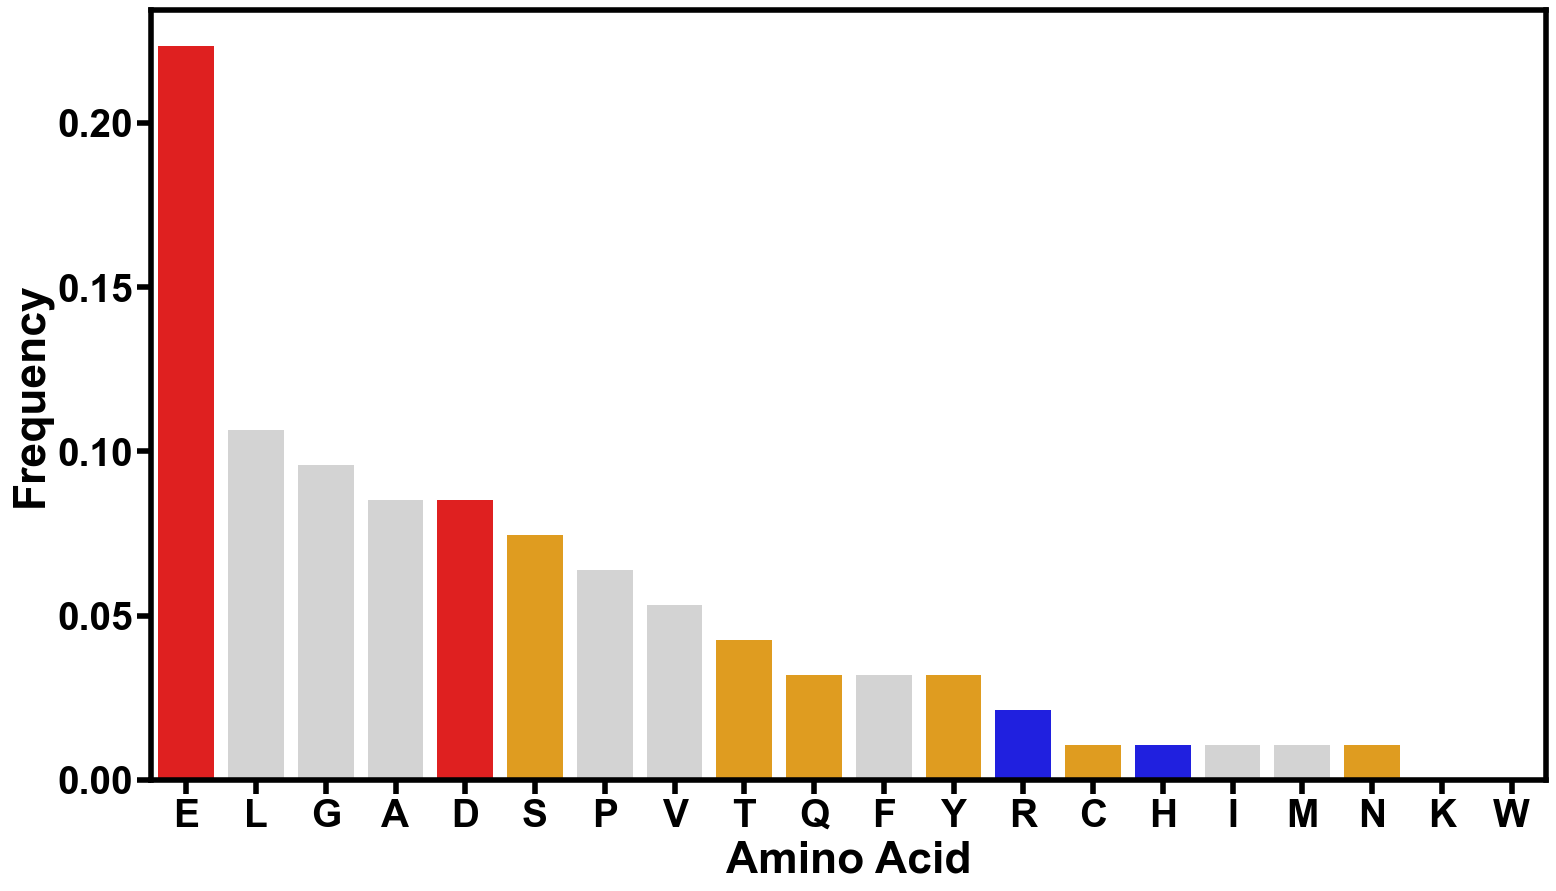

C:\Users\pc\AppData\Local\Temp\ipykernel_10696\3858025875.py:127: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


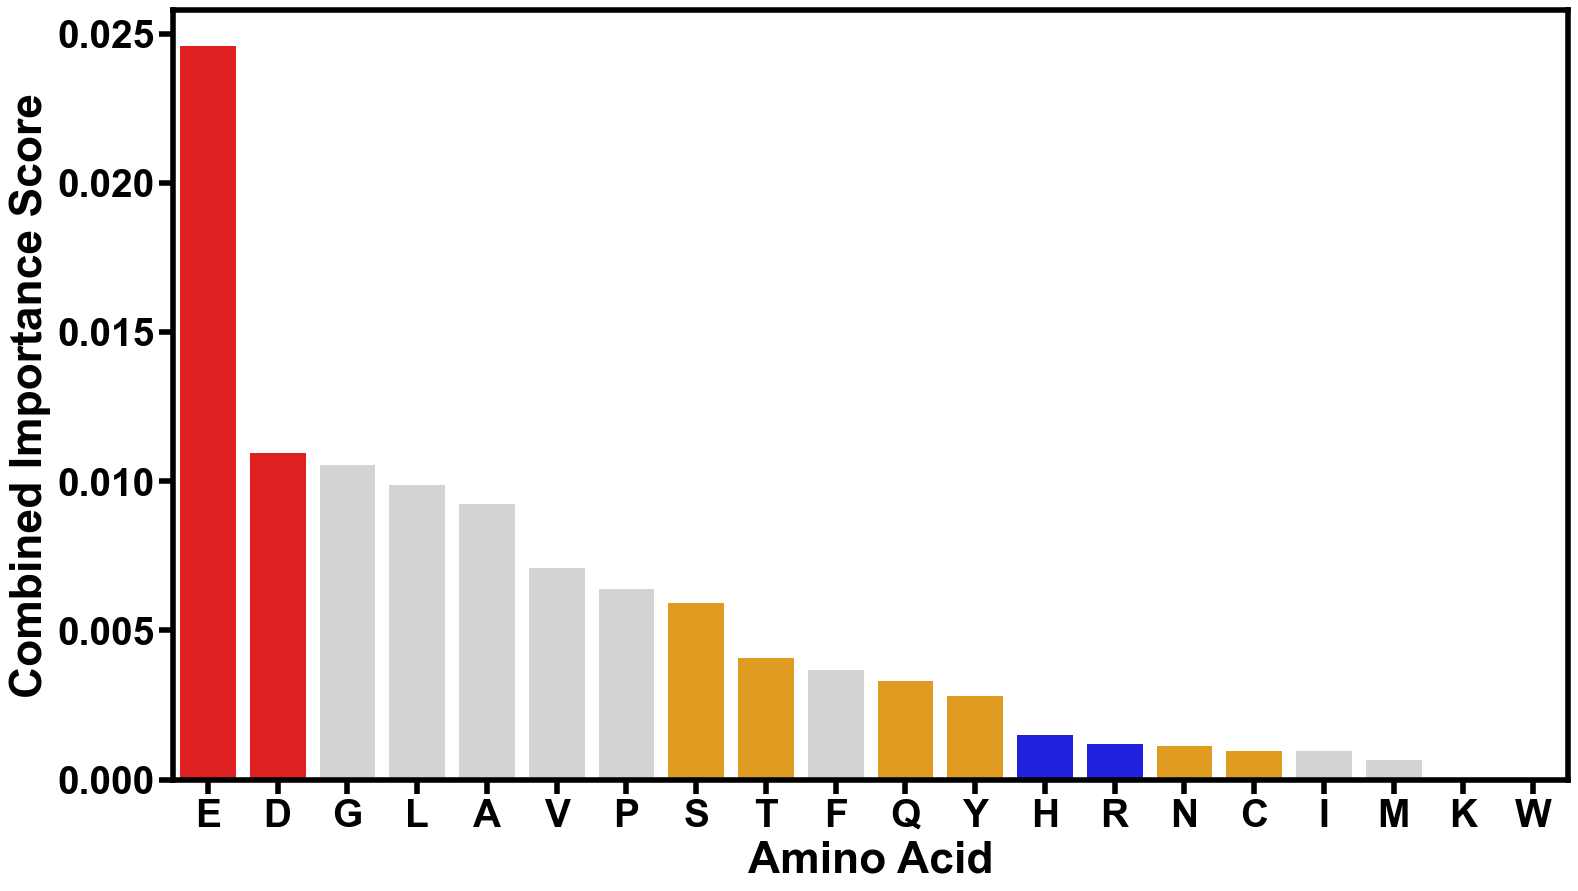

In [10]:

# ===============================
#   执行分析 (带逻辑判断)
# ===============================
OUTPUT_DIRECTORY = r'E:/LLM+XWT/实验结果/attention11.25'
AMINO_ACIDS_LIST = list('ACDEFGHIKLMNPQRSTVWY')
MOTIF_WINDOW = 10

os.makedirs(OUTPUT_DIRECTORY, exist_ok=True)

# 1) 重要性分析 (这里假设 df_importance 已经通过前面的代码生成)
# 如果没有，请取消下面这行的注释：
df_importance = analyze_amino_acid_importance_upgraded(attention_visualization_data, AMINO_ACIDS_LIST, OUTPUT_DIRECTORY)



根据综合重要性排序，最重要的4个氨基酸是: ['E', 'D', 'G', 'L']

--- 开始为核心氨基酸 'E' 生成热力图与序列Logo (无Colorbar) ---


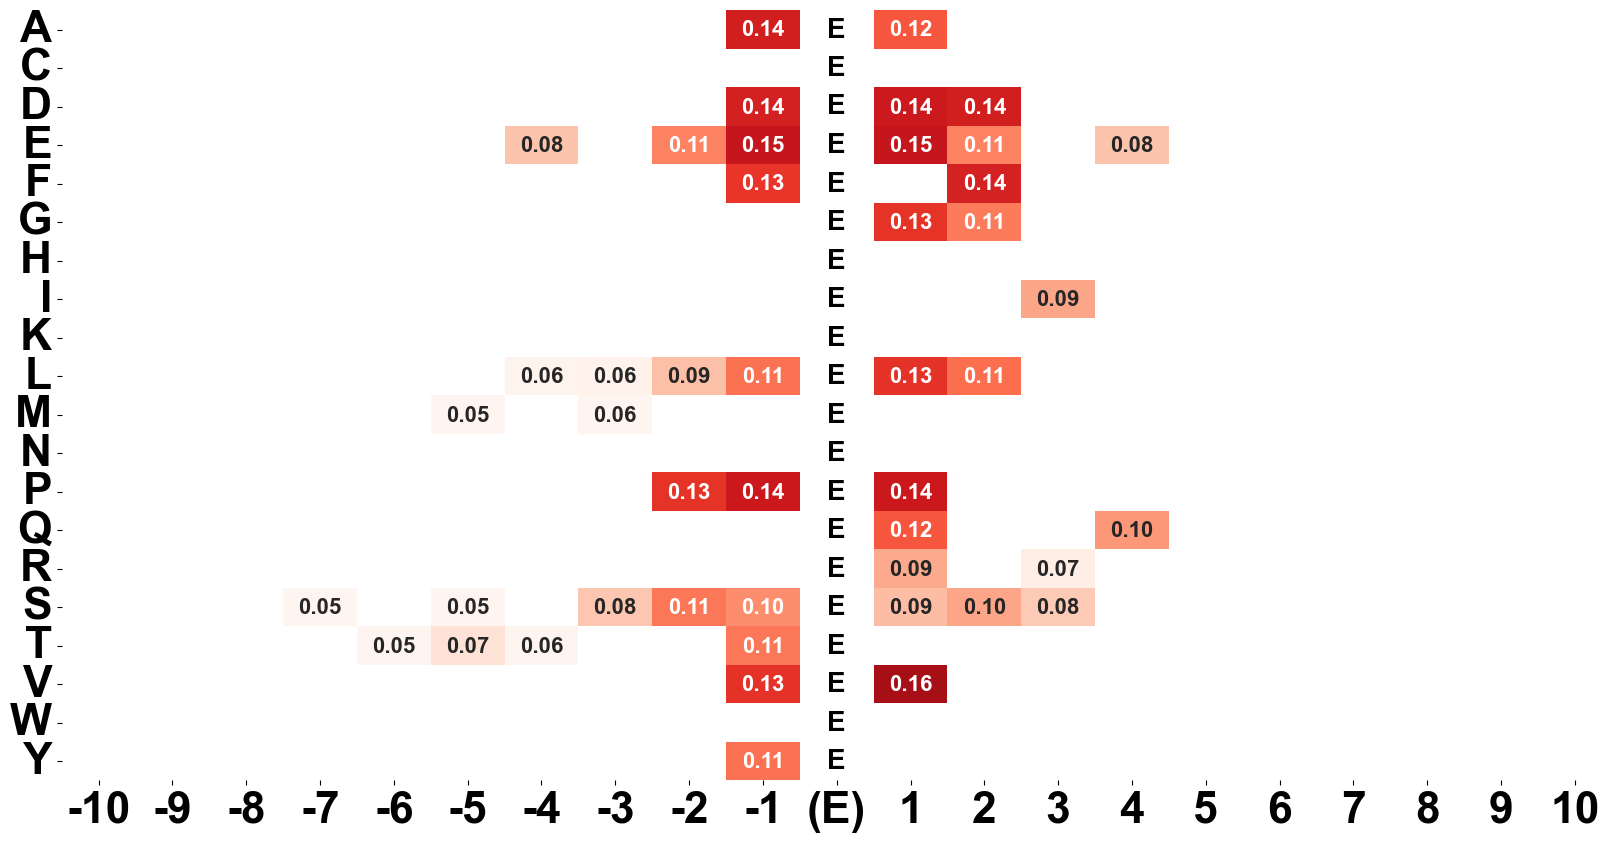

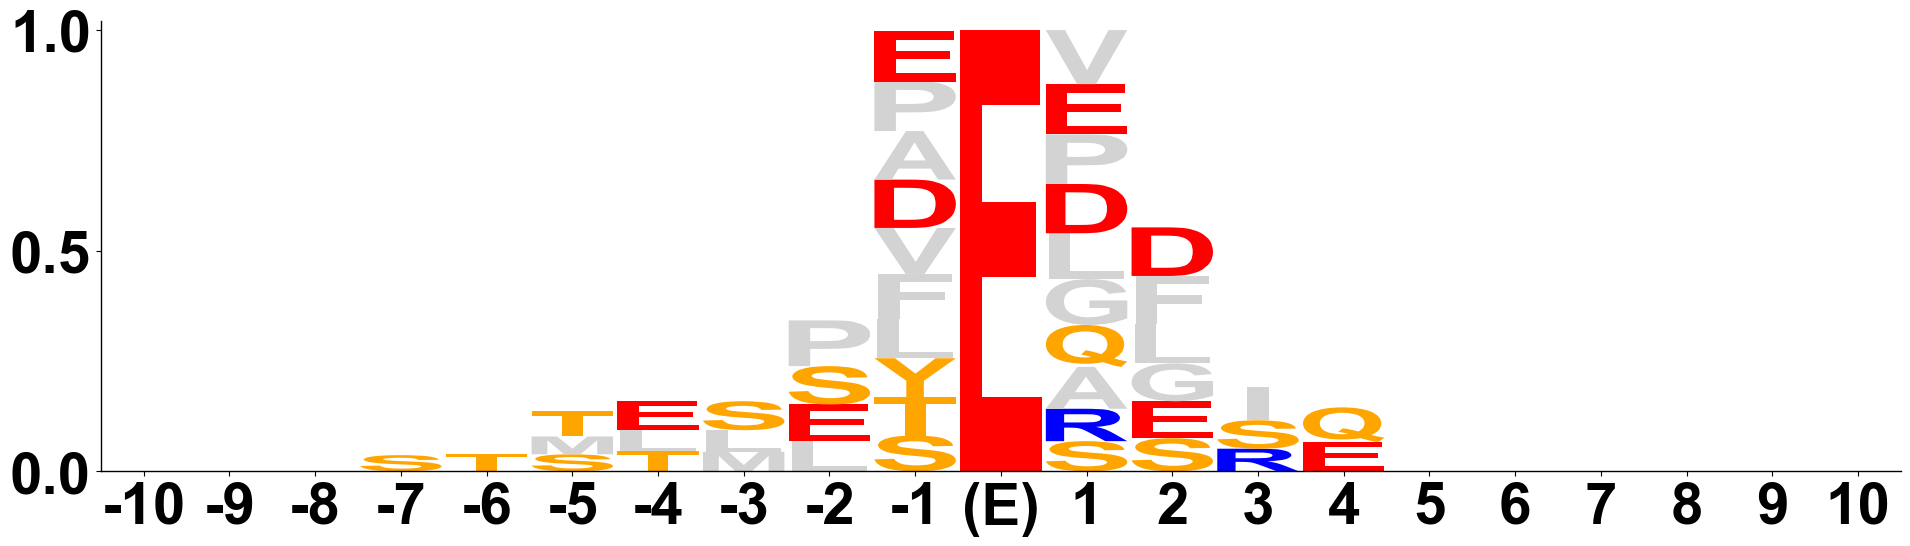


--- 开始为核心氨基酸 'D' 生成热力图与序列Logo (无Colorbar) ---


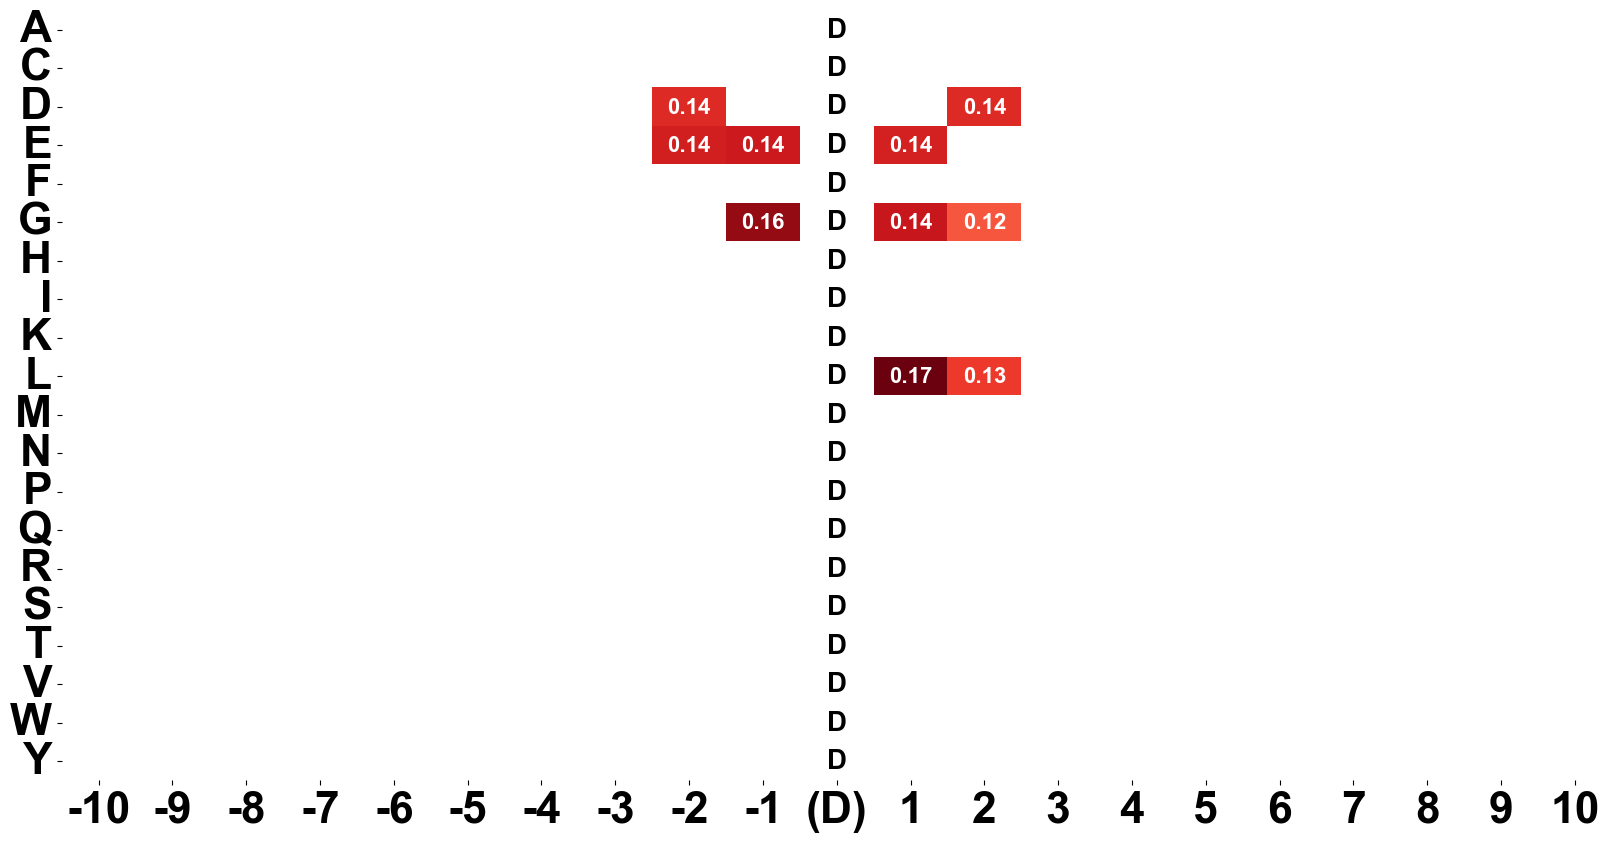

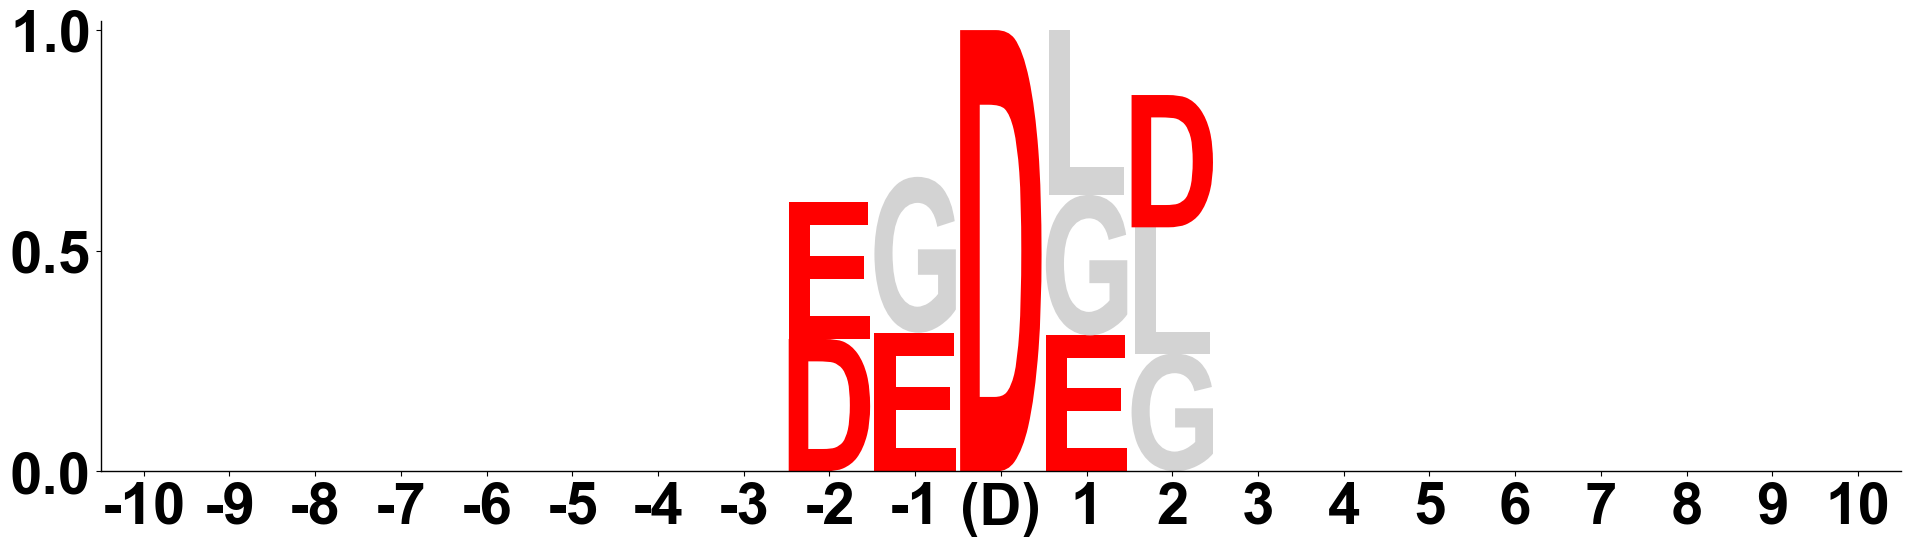


--- 开始为核心氨基酸 'G' 生成热力图与序列Logo (无Colorbar) ---


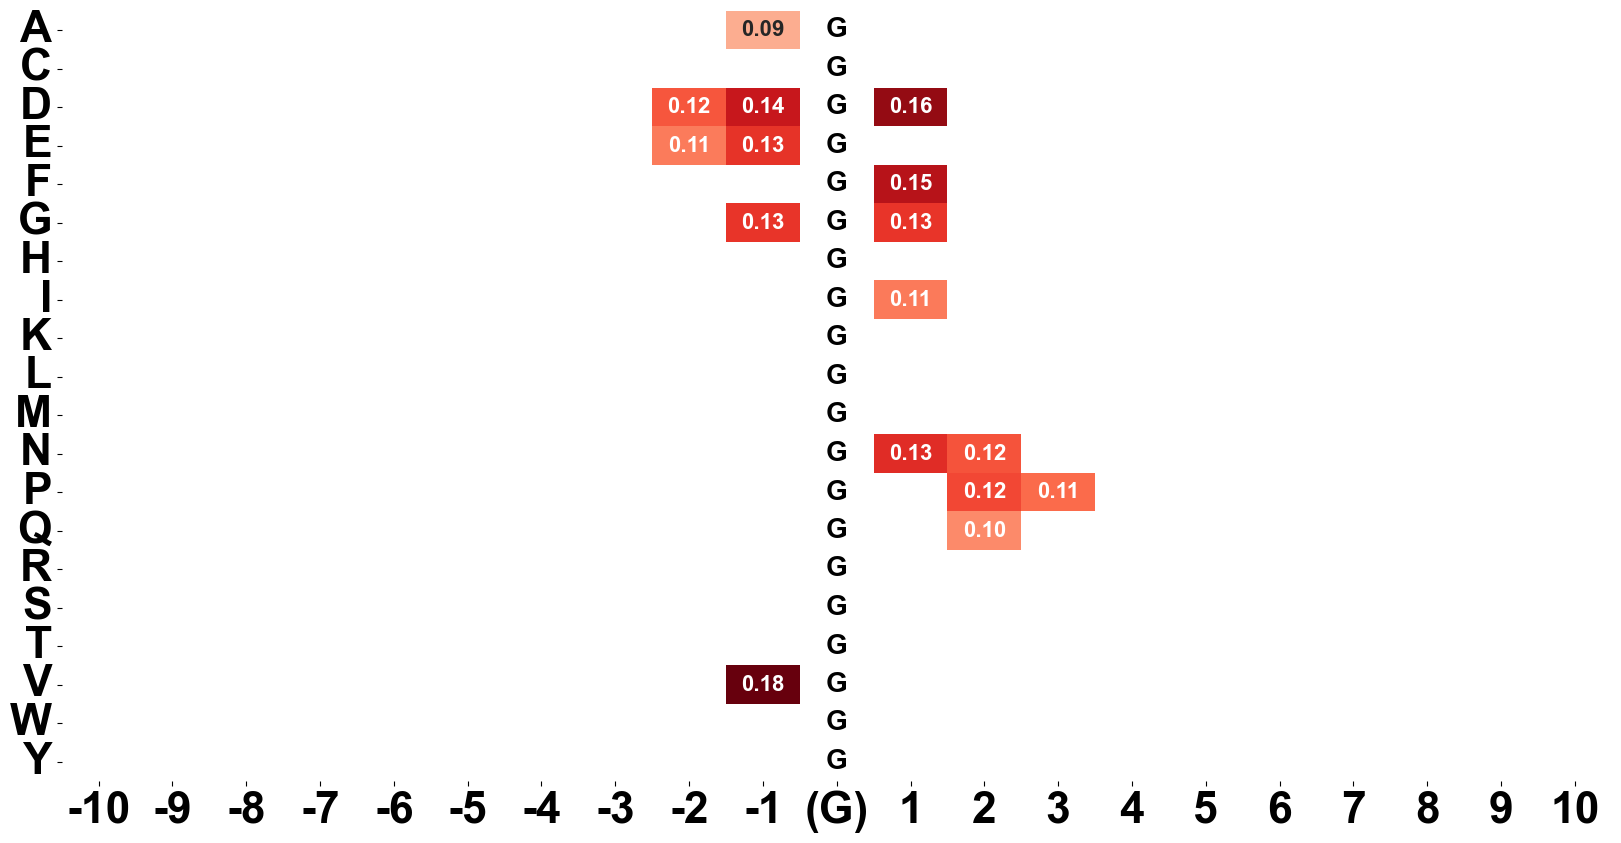

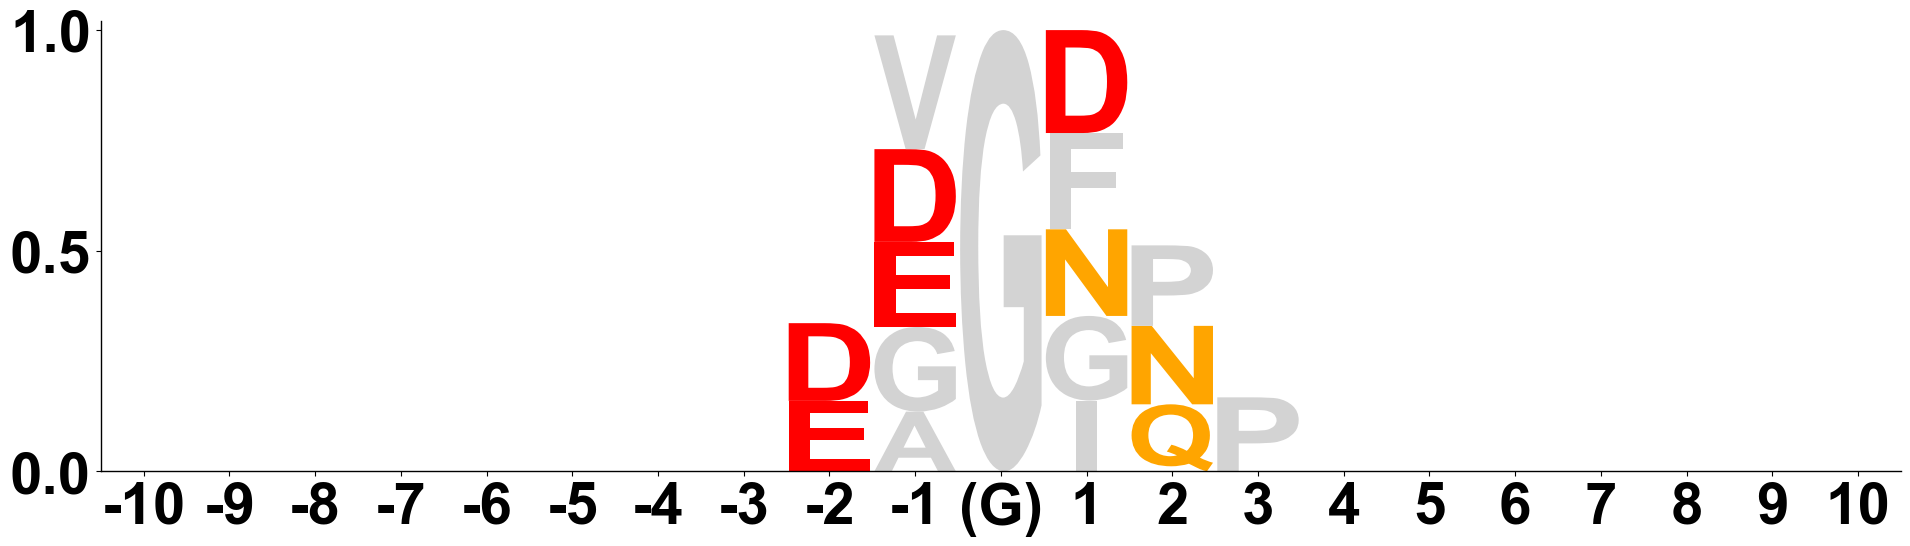


--- 开始为核心氨基酸 'L' 生成热力图与序列Logo (无Colorbar) ---


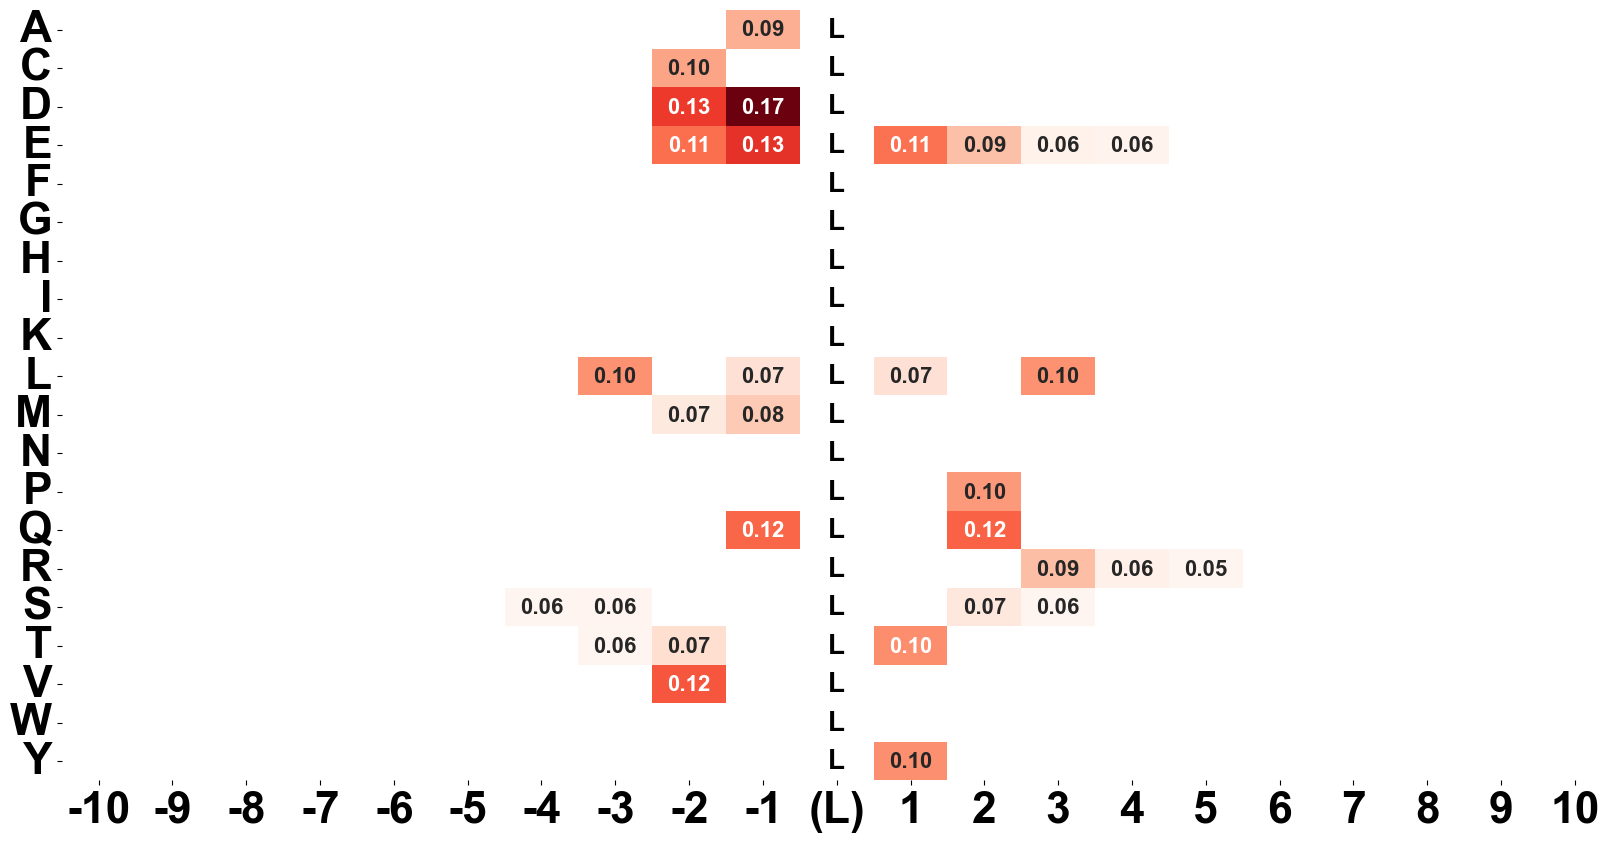

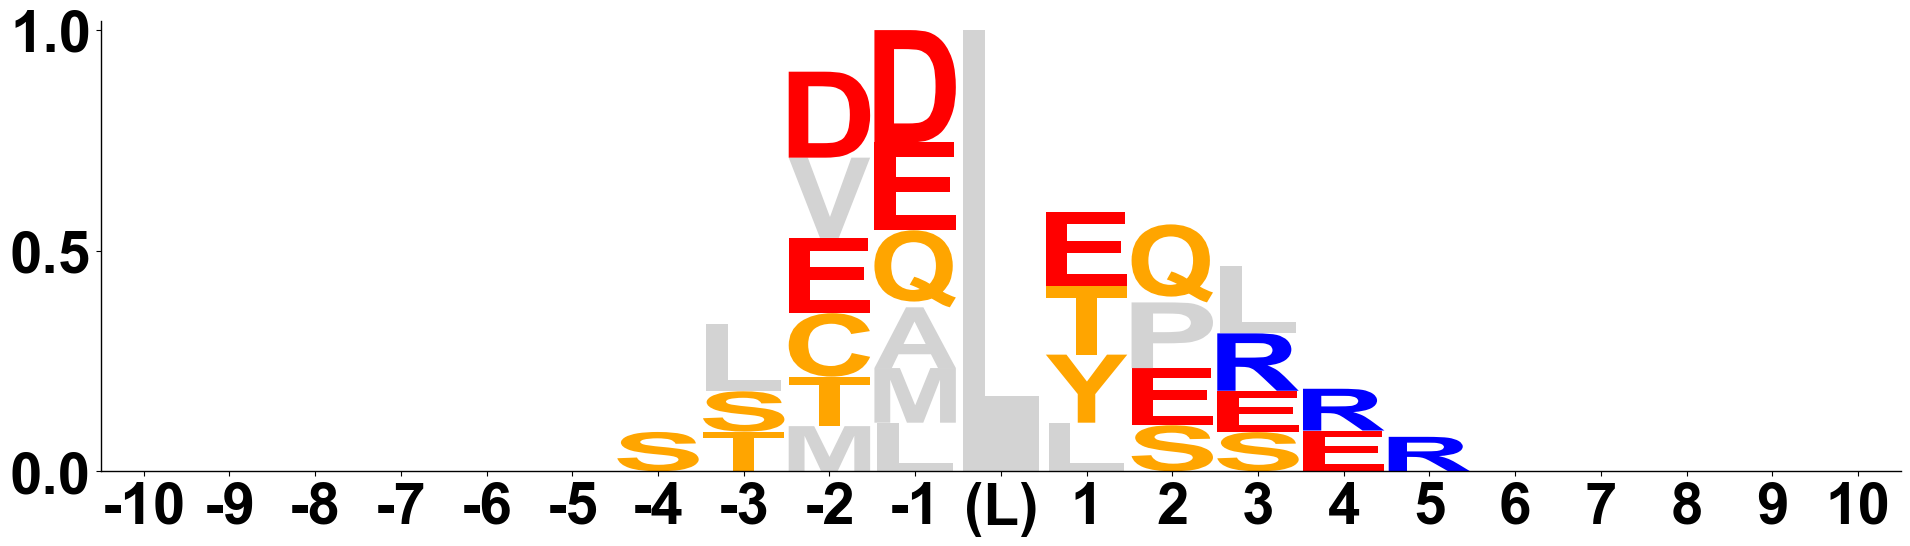


--- 生成独立 Colorbar ---


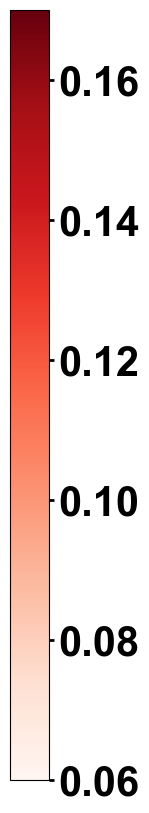

独立 Colorbar 已保存至: E:/LLM+XWT/实验结果/attention11.25\standalone_colorbar.png


In [11]:

# 2) 取前4个氨基酸画图
# 假设排序后结果包含 ['E', 'D', 'G', 'L']
top_amino_acids = df_importance['Amino Acid'].head(4).tolist()

print(f"\n根据综合重要性排序，最重要的4个氨基酸是: {top_amino_acids}")

# === 循环生成热图和Logo ===
for aa in top_amino_acids:
    # 注意：这里删除了 show_cbar 参数，因为函数定义里已经移除了它
    analyze_motif_heatmap_upgraded(
        visualization_data=attention_visualization_data, 
        central_aa=aa, 
        amino_acids=AMINO_ACIDS_LIST, 
        window_size=MOTIF_WINDOW,
        output_dir=OUTPUT_DIRECTORY,
        vmin=0.06,  # 统一最小值
        vmax=0.17   # 统一最大值
    )


# 3) 生成独立 Colorbar
generate_standalone_colorbar(
    output_dir=OUTPUT_DIRECTORY, 
    vmin=0.06, 
    vmax=0.17, 
    height=10 # 与热力图高度一致
)

--- 开始运行 [更新版] 频率与注意力回归分析 ---
回归分析图(含R^2)已保存至: E:/LLM+XWT/实验结果/attention11.25\regression_attention_vs_frequency.png


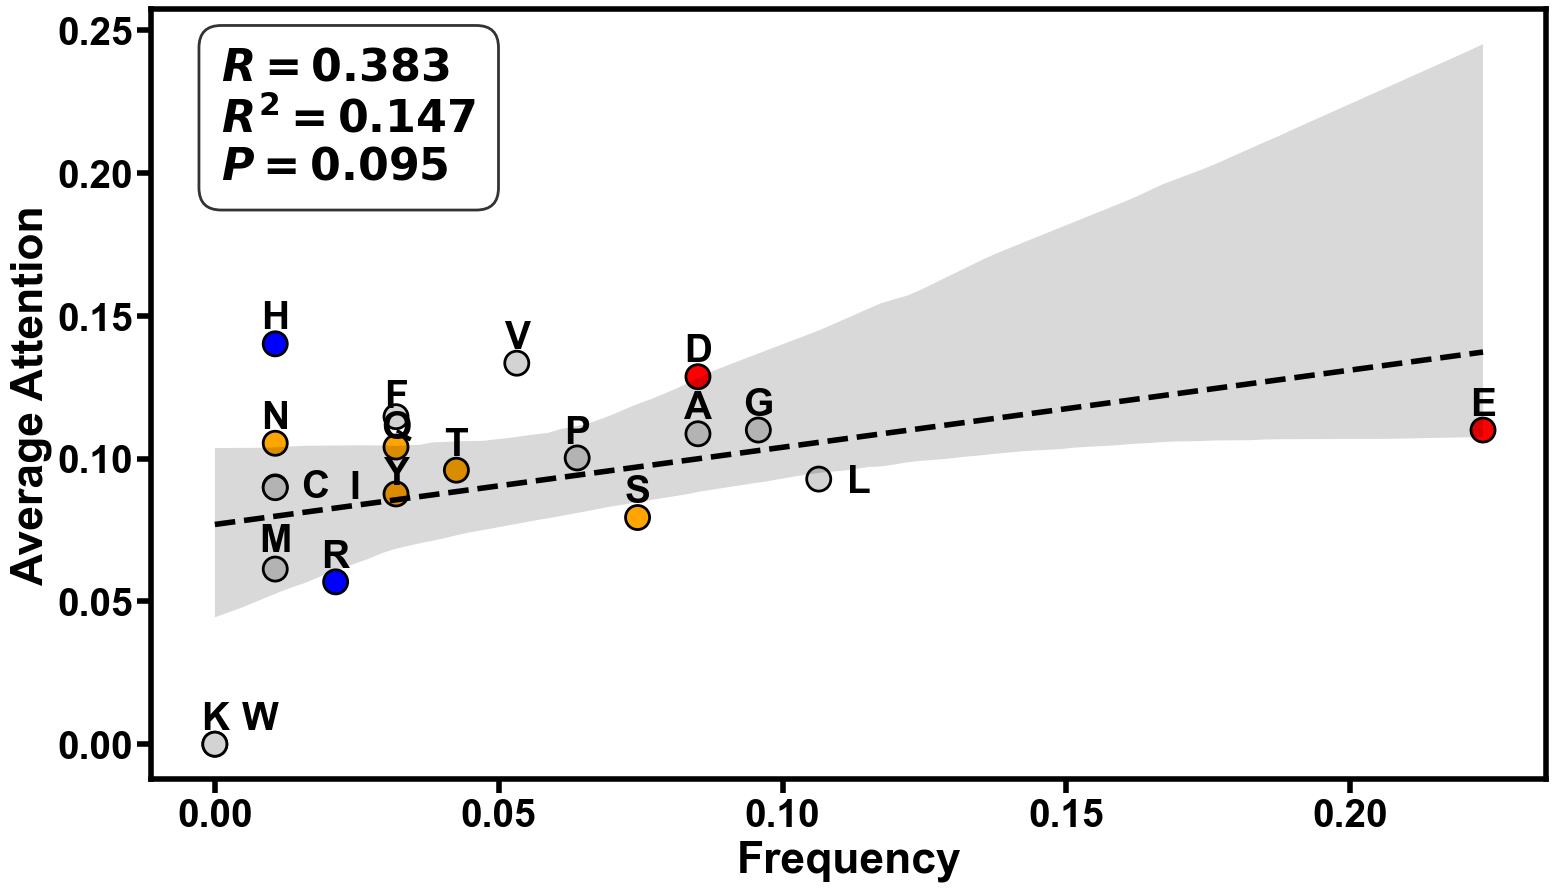

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats
import os

# ===============================
#   [更新版] 频率与注意力回归分析
# ===============================
print("--- 开始运行 [更新版] 频率与注意力回归分析 ---")

# 1. 数据准备 (复用原有逻辑，保持不变)
# ---------------------------------------------------------
target_data = [d for d in attention_visualization_data if d['label'] == 1]
amino_acids_list = AMINO_ACIDS_LIST

# A) 重新计算平均注意力
attention_dict = {aa: [] for aa in amino_acids_list}
for data in target_data:
    avg_layer_attentions = np.mean(data['attentions'], axis=0)
    cls_to_tokens_attention = avg_layer_attentions[0, :]
    for i, token in enumerate(data['tokens'][1:-1]):
        if token in attention_dict:
            attention_dict[token].append(cls_to_tokens_attention[i+1])
avg_attention_map = {aa: np.mean(scores) if scores else 0 for aa, scores in attention_dict.items()}

# B) 重新计算出现频率
frequency_counts = {aa: 0 for aa in amino_acids_list}
total_count = 0
for data in target_data:
    for token in data['sequence']:
        if token in frequency_counts:
            frequency_counts[token] += 1
            total_count += 1
frequency_map = {aa: count / total_count if total_count > 0 else 0 for aa, count in frequency_counts.items()}

# C) 构建 DataFrame
df_regression = pd.DataFrame({
    'Amino Acid': amino_acids_list,
    'Average Attention': [avg_attention_map[aa] for aa in amino_acids_list],
    'Frequency': [frequency_map[aa] for aa in amino_acids_list]
})

# 2. 绘图配置 (字号与线宽控制)
# ---------------------------------------------------------
BORDER_WIDTH = 4       # 边框粗细
TICK_WIDTH = 4         # 刻度线粗细
TICK_LENGTH = 10       # 刻度线长度
LABEL_SIZE = 32        # X/Y轴 标题字号 (Frequency/Attention)
TICK_FONT_SIZE = 28    # 刻度数字号
TEXT_LABEL_SIZE = 28   # 氨基酸字母(如 A, L) 的字号
STATS_FONT_SIZE = 32   # 统计指标(R, P值) 的字号

# 3. 标签位置微调配置 (关键修改点)
# ---------------------------------------------------------
# 格式: '氨基酸': (X轴偏移量, Y轴偏移量)
# 负数向左/下，正数向右/上。单位是数据坐标轴的单位。
# 您可以在这里添加任何重叠的氨基酸进行微调
label_offsets = {
    'A': (0, 0.002), 'C': (0.007, -0.007), 'D': (0, 0.002), 'E': (0, 0.002), 
    'F': (0, 0), 'G': (0, 0.002), 'H': (0, 0.002), 'I': (0.014, -0.007), 
    'K': (0, 0.002), 'L': (0.007, -0.008), 'M': (0, 0.003), 'N': (0, 0.002), 
    'P': (0, 0.002), 'Q': (0, 0), 'R': (0, 0.002), 'S': (0, 0.002), 
    'T': (0, 0.002), 'V': (0, 0.002), 'W': (0.008, 0.002), 'Y': (0, 0)
}

# 4. 绘制回归图
# ---------------------------------------------------------
plt.figure(figsize=(18, 10))
ax = plt.gca()

# 绘制散点
sns.scatterplot(
    data=df_regression, 
    x='Frequency', 
    y='Average Attention', 
    hue='Amino Acid', 
    palette=aa_color_map, 
    s=300, 
    edgecolor='black',
    linewidth=2,
    legend=False,
    ax=ax
)

# 绘制回归线
sns.regplot(
    data=df_regression, 
    x='Frequency', 
    y='Average Attention', 
    scatter=False, 
    color='black', 
    line_kws={'linewidth': 4, 'linestyle': '--'}, 
    ci=95, 
    ax=ax
)

# 标注每个点的氨基酸字母 (应用微调偏移)
for i in range(df_regression.shape[0]):
    row = df_regression.iloc[i]
    aa = row['Amino Acid']
    
    # 获取偏移量，如果没有定义则默认为 (0, 0)
    x_off, y_off = label_offsets.get(aa, (0, 0))
    
    plt.text(
        row['Frequency'] + x_off,           # X 坐标 + 手动偏移
        row['Average Attention'] + 0.0005 + y_off, # Y 坐标 + 基础偏移 + 手动偏移
        aa, 
        horizontalalignment='center', 
        verticalalignment='bottom',
        fontsize=TEXT_LABEL_SIZE,           # 这里控制氨基酸标签字号
        color='black', 
        fontweight='bold'
    )

# 计算统计指标
r_value, p_value = stats.pearsonr(df_regression['Frequency'], df_regression['Average Attention'])
r_squared = r_value ** 2 # 计算 R平方

# 格式化文本 (P值改为小数显示, 3位小数)
stats_text = (f'$R = {r_value:.3f}$\n'
              f'$R^2 = {r_squared:.3f}$\n'
              f'$P = {p_value:.3f}$') # 这里控制 P 值的小数位数

# 显示统计指标
plt.text(0.05, 0.95, stats_text, 
         transform=ax.transAxes, 
         fontsize=STATS_FONT_SIZE,      # 这里控制统计文本字号
         fontweight='bold',
         verticalalignment='top', 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='black', linewidth=2, alpha=0.8))

# 5. 应用样式细节
# ---------------------------------------------------------
for spine in ax.spines.values():
    spine.set_linewidth(BORDER_WIDTH)
ax.tick_params(width=TICK_WIDTH, length=TICK_LENGTH, labelsize=TICK_FONT_SIZE)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_weight('bold')

plt.xlabel('Frequency', fontsize=LABEL_SIZE, fontweight='bold')
plt.ylabel('Average Attention', fontsize=LABEL_SIZE, fontweight='bold')

# 6. 保存并显示
# ---------------------------------------------------------
save_path_reg = os.path.join(OUTPUT_DIRECTORY, 'regression_attention_vs_frequency.png')
plt.savefig(save_path_reg, dpi=600, bbox_inches='tight')
print(f"回归分析图(含R^2)已保存至: {save_path_reg}")
plt.show()